# PreRequisite

In [ ]:
# IMPORTS
import io
import cv2
import sys
import time
import joblib
import hashlib
import imginfo
import datetime
import threading
import numpy as np
import pandas as pd
import functions as fn
import tensorflow as tf
import dataTransfer as DT
import FingerBiometrics as FB
import matplotlib.pyplot as plt
import EncryptionDecryption as ED
import accelerometerModelTraining as AT

In [ ]:
# Define the path to the directory containing the module
module_dir = "../Main/RequiredFuntions"

# Append the directory to sys.path
sys.path.append(module_dir)

# Initialization phase

In [ ]:
import InitializationPhase as IP

# GENERATING PUBLIC AND PRIVATE KEYS FOR USER
USER = IP.ECCPublicPrivateKeyGeneration()

# GENERATING PUBLIC AND PRIVATE KEYS FOR GATEWAY
GATEWAY = IP.ECCPublicPrivateKeyGeneration()

# GENERATING SYMMETRIC KEYS
preSharedSymmetricKeys = IP.SymmetricKeyGeneration()

# USER - REGISTRATION PHASE

In [5]:
# step 1
fingerprintImagePath = "../Main/RequiredData/Fingerprint/5.jpg"
accelerometerDataPath = "../Main/RequiredData/Accelerometer/m55s_training.csv"

In [ ]:
uniqueId_i = "RajeshDevice1"

imageHash = fn.hash_file(fingerprintImagePath)

accelerometerHash = fn.hash_file(accelerometerDataPath)

userNonce_i = fn.nonce_gen()

compute_i = hashlib.sha256((uniqueId_i 
                                + imageHash
                                + accelerometerHash
                                + str(userNonce_i)
                                + preSharedSymmetricKeys
                                ).encode()
                            ).hexdigest()

encryptedIdandImage = ED.symmetric_key_encryption(uniqueId_i, 
                                                  ED.read_image_as_bytes(fingerprintImagePath), 
                                                  preSharedSymmetricKeys)

encryptedIDandAccelerometerData = ED.symmetric_key_encryption(uniqueId_i,
                                                              ED.read_image_as_bytes(accelerometerDataPath), 
                                                              preSharedSymmetricKeys)

In [ ]:
FingerImageMetaData = imginfo.extract_metadata(fingerprintImagePath)
CSVFileMetaData = imginfo.extract_metadata(accelerometerDataPath)

encryptedFingerImageMetaData = ED.encryption(FingerImageMetaData, GATEWAY[0])
encryptedCSVFileMetaData = ED.encryption(CSVFileMetaData, GATEWAY[0])

In [8]:
userDeviceData = {
    "encryptedIdandImage" : encryptedIdandImage,
    "encryptedIDandAccelerometerData" : encryptedIDandAccelerometerData,
    "imageHash" : imageHash,
    "accelerometerHash" : accelerometerHash,
    "userNonce" : userNonce_i,
    "compute" : compute_i,
    "FingerImageMetaData" : encryptedFingerImageMetaData,
    "CSVFileMetaData" : encryptedCSVFileMetaData
}


In [9]:
# Create and start threads
thread1 = threading.Thread(target=DT.receive)  # Start the receive function
thread2 = threading.Thread(target=DT.send, args=(userDeviceData,))  # Start the send function with arguments

thread1.start()
time.sleep(2)  # Ensure the server starts before sending
thread2.start()

# Wait for threads to complete
thread1.join()
thread2.join()

print("Data transfer and storage complete.")

Server is listening on port 12345...
Connected by ('127.0.0.1', 45446)
Data transfer done.
Received data saved to 'received_data.json'.
Data transfer and storage complete.


In [10]:
# step 2
print("Starting Step 2")
json_data = fn.read_json_file("../Main/ReceivedData/received_data.json")

Starting Step 2


In [11]:
decryptedIdandImage = ED.symmetric_key_decryption(json_data["encryptedIdandImage"], 
                                                  preSharedSymmetricKeys)

decryptedIDandAccelerometerData = ED.symmetric_key_decryption(json_data["encryptedIDandAccelerometerData"], 
                                                              preSharedSymmetricKeys)

print(f"both the above decryptions gave the same output unique id : {decryptedIdandImage[0] == decryptedIDandAccelerometerData[0]}")

print("image hash validated : ", hashlib.sha256(decryptedIdandImage[1]).hexdigest() == json_data["imageHash"])

both the above decryptions gave the same output unique id : True
image hash validated :  True


In [12]:
validationCompute_i = hashlib.sha256((decryptedIdandImage[0].decode() + 
                                      hashlib.sha256(decryptedIdandImage[1]).hexdigest() + 
                                      hashlib.sha256(decryptedIDandAccelerometerData[1]).hexdigest() + 
                                      str(json_data["userNonce"]) +
                                      preSharedSymmetricKeys).encode()).hexdigest()

In [13]:
if(validationCompute_i == json_data["compute"]): print("validation for compute status : \"success\"")
else: print("validation \"failed\" ")

validation for compute status : "success"


In [14]:
baseAccelerometerData = "../Main/RequiredData/Accelerometer/baseTrainingData.csv"

import functions as fn
fn.AddNewDevice(1, "defaultUser1")

🎯 Encrypted Data Saved for Training ID `1` in DB/DeviceList.hdf5


'success'

In [15]:
gatewayUniqueId_i = "rajeshGateway"

In [16]:
# creating devicelist for default device for training (assuming already a device just for training purposes)
NewUser = fn.GetNewDeviceID(fn.load_all_data("../Main/DB/DeviceList.hdf5"))
fn.AddNewDevice(NewUser, decryptedIdandImage[0].decode())

sorted_data = 1
🎯 Encrypted Data Saved for Training ID `2` in DB/DeviceList.hdf5


'success'

In [ ]:
baseDF = pd.read_csv(baseAccelerometerData)

In [18]:
df = pd.read_csv(io.StringIO(decryptedIDandAccelerometerData[1].decode('UTF-8')))
df = df.dropna()
df = df.drop(columns=["Var1_Timestamp", "Var2_Timestamp", "Var3_Timestamp"])
df["user"] = NewUser
df.head()

,X,Y,Z,user
0,0.342174,0.021535,10.399805,2
1,-0.064606,0.160319,9.241081,2
2,0.126820,0.098106,9.796216,2
3,0.284746,0.031107,10.237094,2
4,0.098106,0.098106,9.710074,2


In [19]:
Combined_training_data = pd.concat([baseDF, df], ignore_index=True)
Combined_training_data.to_csv(baseAccelerometerData, index=False)

In [ ]:

TrainingThread = threading.Thread(target=AT.AccelerometerTraining, args=(Combined_training_data,))
TrainingThread.start()

print("waiting for 10sec......")
time.sleep(10)

waiting for 10sec......


Models Saved Successfully!


In [ ]:
# checking the liveness of the image
fingerprintModel = joblib.load('./Model/Fingerprint/naive_bayes_fingerprint_model.pkl')
fingerprintPrediction = FB.predict_fingerprint(decryptedIdandImage[1], (200,200), fingerprintModel)
print(f"The fingerprint is: {fingerprintPrediction}")

2025-03-31 19:35:39.962778: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743429939.987685   12379 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743429939.995173   12379 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743429940.012724   12379 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743429940.012759   12379 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743429940.012762   12379 computation_placer.cc:177] computation placer alr

The fingerprint is: Real


/media/asvskr/DATA/study/FinalProject/.venv/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianNB from version 1.3.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


    #   should add a break statement if image is fake

I0000 00:00:1743429975.579503   12379 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2603 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1743429989.374613   12522 cuda_dnn.cc:529] Loaded cuDNN version 90300


Detection and cropping completed.


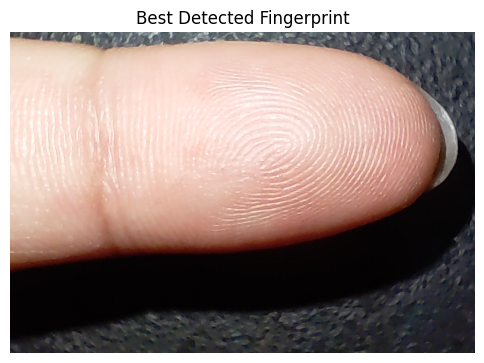

In [ ]:
# isolate the finger from the image


model = tf.saved_model.load('./Model/Fingerprint/ssd_mobilenet_v2_320x320_coco17_tpu-8/saved_model')
image_np = FB.load_image_into_numpy_array(decryptedIdandImage[1])
detections = FB.detect_objects(image_np, model)

boxes = detections['detection_boxes'][0].numpy()
scores = detections['detection_scores'][0].numpy()
classes = detections['detection_classes'][0].numpy().astype(np.int32)

cropped_image, image_with_boxes = FB.draw_best_box(image_np, boxes, scores, classes)

print("Detection and cropping completed.")

if cropped_image is not None:
    plt.figure(figsize=(6, 6))
    plt.imshow(cropped_image)
    plt.axis("off")  # Hide axes
    plt.title("Best Detected Fingerprint")
    plt.show()
else:
    print("❌ No valid cropped image found.")


In [23]:
# saving image to bytes

_, buffer = cv2.imencode('.jpg', cropped_image)
fingerImage = buffer.tobytes()

#read the image
# nparr = np.frombuffer(image_bytes, np.uint8)  # Convert byte data to NumPy array
#         img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)  # Decode the image using OpenCV

In [24]:
hashedGatewayID = hashlib.sha256(gatewayUniqueId_i.encode()).hexdigest()
hashedUniqueId_i = hashlib.sha256(uniqueId_i.encode()).hexdigest()

In [ ]:
lastlogin = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S:%s")

fn.lastlogin(hashlib.sha256((gatewayUniqueId_i+uniqueId_i).encode()).hexdigest(), lastlogin)

✅ New lastLogin entry for 7e42a793b84e284557e5f8615b18b93e7b9dc1d226bb1228b71a9e2b6538fa51 created


In [26]:
# varables needed to save in DB

# encrypt image using pubic key (gateway)
_, buffer = cv2.imencode('.jpg', cropped_image)
encryptedImage = ED.encryption(buffer.tobytes(), GATEWAY[0])

# calling functions to save data to DB
fn.UpdateRegisteredDevices(hashedGatewayID, 
                           hashedUniqueId_i, 
                           encryptedImage,
                           encryptedFingerImageMetaData, 
                           encryptedCSVFileMetaData)

Data for GatewayID: 5ca23dfa5da73d8652885c9816641e209c35d3cddfb8668acf120285d0e43ec0, UniqueID: 22ed9bc0923ae1364a5125276e9a17f40b2cfbdfeccc5fd51f212f8a9cc3032b successfully updated.


In [27]:
fn.load_all_data("../Main/DB/DeviceList.hdf5")

{'1': {'uniqueID': '7c5d80c86b4d482a7d1a822901eedfad46c97f0aa241b7ee6ce39d25f6a39a92'},
 '2': {'uniqueID': '22ed9bc0923ae1364a5125276e9a17f40b2cfbdfeccc5fd51f212f8a9cc3032b'}}

In [28]:
fn.load_all_data("../Main/DB/lastlogin.hdf5")

{'7e42a793b84e284557e5f8615b18b93e7b9dc1d226bb1228b71a9e2b6538fa51': {'lastLogin': '2025-03-31 19:36:32:1743429992'}}

In [29]:
fn.load_all_data("../Main/DB/registeredDevices.hdf5")

{'5ca23dfa5da73d8652885c9816641e209c35d3cddfb8668acf120285d0e43ec0': {'22ed9bc0923ae1364a5125276e9a17f40b2cfbdfeccc5fd51f212f8a9cc3032b': {'accelMetadata': '2DMG/MCbt1Xqh9z2BEvqiMlr/ZK2CCBqHmBaUphjXJG2A0FrmUJzOZA9xijPn5Hmq2KH+gtW/ePPXGozn0ZI055ugDqxJpa/1s+aUIlTqYwuzIXjuCT9PR4iiltn7DvDADtoWZvJzKr2NyeB6T0vh/EqrJ1s1KS2wzUXex35BFG5tztjwUpsphgXQhHOnbCBoZ6xX8seQrQpQZz51Tp/uGaGlf+ROBttEyEleJKZQDFi1xdb3JYBJzifN9sTdDCHoZn/RLCFYdnyrrT56t608nXSYVosjj7zj0vXfYIlARotLS0tLUJFR0lOIFBVQkxJQyBLRVktLS0tLQpNRmt3RXdZSEtvWkl6ajBDQVFZSUtvWkl6ajBEQVFjRFFnQUVEMDNscTNqZGJGbEptRmppM3VNY3RhSHFicWtLCmUySGZMUWRQWEc0WXZ2WVU5cE0vVmNXK2dtS2NqQzVjVXdDRGZwVzF3cFlIb3QvdWRndW1raUdXMlE9PQotLS0tLUVORCBQVUJMSUMgS0VZLS0tLS0K',
   'encrypted_image': '...',
   'imageMetadata': 'X/1dzOHM+fyv3gKG/Ssh76C1fFQyhF1eQxEBCqpcHQw8CUbck2XN96lBWleG8QQfmzfhr2ytl7YDpWA+T4T82i2eUxmfb0a0Av5tObTb4xQdM9yYbZEgjPtGOLIvdz5sAbvb8p5h4sDLVR+GE5vcIEy2SSV4Pqr6p4AfXCDhd+yvQysuMgKyF43dU/HIVYSOo7ct75I+Z+SblHOr2ieKwiK5DMoUUfxqt73d3g/HbVTk8pk9suM1CioUagCSH8

In [30]:
#generate nounce in gateway
gatewayNonce_i = fn.nonce_gen()

Secret_i = int(gatewayNonce_i) ^ int(userDeviceData["userNonce"])

In [64]:
Secret_i

24

In [63]:
gatewayNonce_i

692

In [31]:
# shares generated by gateway
generatedRandomNumber = int(fn.nonce_gen())
sharesGeneratedByGateway = (Secret_i + (2 * generatedRandomNumber)) % fn.primeNumbergenerator()

In [69]:
sharesGeneratedByGateway

59

In [32]:
secretIntegrity_i = hashlib.sha256(
    (hashlib.sha256((str(Secret_i) + decryptedIdandImage[0].decode()).encode()).hexdigest() + str(userDeviceData["userNonce"])).encode()).hexdigest()

In [33]:
# temporal identity to encrypt R and gatwayNonce

temporalIdentity_i = hashlib.sha256((decryptedIdandImage[0].decode() + str(userDeviceData["userNonce"]) + USER[0].decode()).encode()).hexdigest()

In [34]:
# generatedRandomNumber_bytes = generatedRandomNumber.to_bytes((generatedRandomNumber.bit_length() + 7) // 8, byteorder='big')
# gatewayNonce_bytes = gatewayNonce_i.to_bytes((gatewayNonce_i.bit_length() + 7) // 8, byteorder='big')

# # XOR the values
# encryptedRandomNumber = bytes([b ^ g for b, g in zip(generatedRandomNumber_bytes, temporalIdentity_i.encode())])
# encryptedRandomNumber = bytes([b ^ g for b, g in zip(encryptedRandomNumber, preSharedSymmetricKeys.encode())])

# encryptedGatewayNonce = bytes([b ^ g for b, g in zip(gatewayNonce_bytes, temporalIdentity_i.encode())])
# encryptedGatewayNonce = bytes([b ^ g for b, g in zip(encryptedGatewayNonce, preSharedSymmetricKeys.encode())])

In [35]:
encryptedRandomNumber = fn.xor_strings(str(generatedRandomNumber), temporalIdentity_i)
encryptedRandomNumber = fn.xor_strings(encryptedRandomNumber, preSharedSymmetricKeys)

encryptedGatewayNonce = fn.xor_strings(str(gatewayNonce_i), temporalIdentity_i)
encryptedGatewayNonce = fn.xor_strings(encryptedGatewayNonce, preSharedSymmetricKeys)

In [37]:
gatewaySecondNonce_i = fn.nonce_gen()

temporalIdentityGateway = hashlib.sha256((gatewayUniqueId_i + GATEWAY[0].decode() + str(gatewaySecondNonce_i)).encode()).hexdigest()

compute_G = hashlib.sha256((
    temporalIdentityGateway + 
    secretIntegrity_i + 
    encryptedRandomNumber + 
    encryptedGatewayNonce + 
    str(gatewaySecondNonce_i)).encode()).hexdigest()

In [38]:
# saving the necesssay values
fn.gatewayStore(decryptedIdandImage[0].decode(), hashlib.sha256((str(Secret_i) + decryptedIdandImage[0].decode()).encode()).hexdigest(), sharesGeneratedByGateway)

updated gateway storage


In [39]:
fn.load_all_data("../Main/DB/gatewayStorage.hdf5")

{'RajeshDevice1': {'encryptedSecret': 'd54404ed4bad5fec339111a2967946ba953abd4fc38c845a75d0866d7a791e15',
  'usershare': np.int64(59)}}

In [41]:
gatewayJson = {
    'secretIntegrity' : secretIntegrity_i,
    'encryptedRandomNumber' : encryptedRandomNumber,
    'encryptedGatewayNonce' : encryptedGatewayNonce,
    'gatwayNonce' : gatewaySecondNonce_i,
    'computeG' : compute_G
}

In [42]:
# Create and start threads
thread1 = threading.Thread(target=DT.receive, args=('received_data_gateway.json',))  # Start the receive function
thread2 = threading.Thread(target=DT.send, args=(gatewayJson,))  # Start the send function with arguments

thread1.start()
time.sleep(2)  # Ensure the server starts before sending
thread2.start()

# Wait for threads to complete
thread1.join()
thread2.join()

print("Data transfer and storage complete.")

Server is listening on port 12345...
Connected by ('127.0.0.1', 50534)
Data transfer done.
Received data saved to 'received_data.json'.
Data transfer and storage complete.


    # step 3

In [43]:
# step 2
print("Starting Step 2")
gatewayJsonData = fn.read_json_file("../Main/ReceivedData/received_data_gateway.json")

Starting Step 2


In [44]:
#compute temporal identity user
temporalIdentity_i_s3 = hashlib.sha256((uniqueId_i + str(userNonce_i) + USER[0].decode() ).encode()).hexdigest()

#compute temporal indentity gateway
temporalIdentity_g_s3 = hashlib.sha256((gatewayUniqueId_i + GATEWAY[0].decode() + str(gatewayJsonData['gatwayNonce'])).encode()).hexdigest()

In [45]:
validateComputeG = hashlib.sha256((temporalIdentity_g_s3 + 
                    gatewayJsonData['secretIntegrity'] + 
                    str(gatewayJsonData['encryptedRandomNumber']) + 
                    str(gatewayJsonData['encryptedGatewayNonce']) + 
                    str(gatewayJsonData['gatwayNonce'])).encode()).hexdigest()

In [46]:
# ExtractRandomNumber = gatewayJsonData['encryptedRandomNumber'] ^ 

In [47]:
gatewayJsonData['encryptedRandomNumber']

'J\x15l'

In [48]:
temporalIdentity_i_s3

'2d0129439457cbab16eea1fa5e23a61f0ae51266d778a70f777dce66b6554e3f'

In [49]:
preSharedSymmetricKeys

'MDk3SapupybCiqJ1KtAziKy6lIbkMElATITccLR/U9c='

In [50]:
# randomNumberBytes = bytes.fromhex(gatewayJsonData['encryptedRandomNumber'])

In [51]:

# # XOR the values
# encryptedRandomNumber = bytes([b ^ g for b, g in zip(generatedRandomNumber_bytes, temporalIdentity_i.encode())])
# encryptedRandomNumber = bytes([b ^ g for b, g in zip(encryptedRandomNumber, preSharedSymmetricKeys.encode())])
# 

In [52]:
# gatewayNonce_bytes = gatewayNonce_i.to_bytes((gatewayNonce_i.bit_length() + 7) // 8, byteorder='big')

In [59]:
gatewayJsonData['encryptedRandomNumber']

'J\x15l'

In [60]:
GatewayRandomNumber = fn.xor_strings(gatewayJsonData['encryptedRandomNumber'], temporalIdentity_i_s3)
GatewayRandomNumber = fn.xor_strings(GatewayRandomNumber, preSharedSymmetricKeys)
GatewayRandomNumber

'557'

In [58]:
gatewayJsonData['encryptedGatewayNonce']

'I\x19i'

In [61]:
GatewayGeneratedNonce = fn.xor_strings(str(gatewayJsonData['encryptedGatewayNonce']), temporalIdentity_i_s3)
GatewayGeneratedNonce = fn.xor_strings(GatewayGeneratedNonce, preSharedSymmetricKeys)

In [62]:
GatewayGeneratedNonce

'692'

In [65]:
secretComputed = int(userNonce_i) ^ int(GatewayGeneratedNonce)
secretComputed

24

In [67]:
userShare = (secretComputed + int(GatewayRandomNumber)) % fn.primeNumbergenerator()

In [68]:
userShare

51

In [70]:
(secretComputed + 2 * int(GatewayRandomNumber)) % fn.primeNumbergenerator()

17

In [74]:
validationSecretIntegrity = hashlib.sha256(
    (hashlib.sha256((str(secretComputed) + uniqueId_i).encode()).hexdigest() + str(userNonce_i)).encode()).hexdigest()

In [76]:
validationSecretIntegrity == secretIntegrity_i

True